# LambdaRank on LETOR4
### Learning to Rank — Lambda Gradient Approach
---
**Dataset**: LETOR4 (MQ2008)  
**Model**: ScoringMLP(MLP) trained with LambdaRank lambda gradients   
**Gradients**: Lambda(λ)  
**Metrics**: NDCG@K

## Project Overview

This notebook implements **LambdaRank**. Note: The underlying neural network is
exactly the same as the Pointwise and RankNet notebooks. The only thing that changes
here is how we calculate the error (the training signal) using Lambda gradients.

Instead of defining a scalar loss function and differentiating it, LambdaRank
directly injects gradient signals (λ values) into the network's backward pass.
Each λ_i encodes both the **direction** (should the score go up or down?) and
**magnitude** (by how much, weighted by NDCG impact?) of the update.

### What this notebook covers

| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset extraction |
| 3    | Data loading via `ltr.data.load_fold` |
| 4    | Model definition using `ltr.models.ScoringMLP` |
| 5    | How Lambda gradients are computed |
| 6    | Training with direct gradient injection |
| 7    | 5-Fold Evaluation (Standard LETOR Folds) |
| 8    | Ablation study across 4 architectures |


## Step 1 · Colab Setup & Package Installation

In [1]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# This cell clones the repo (if needed) and installs the ltr package.
# Change REPO_PATH if you cloned to a different location.
import os, subprocess, sys

REPO_PATH = "/content/Learning-To-Rank-for-Search"

if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone",
         "https://github.com/navaneeswar854/Learning-To-Rank-for-Search.git",
         REPO_PATH],
        check=True,
    )
    print("Repo cloned.")
else:
    print("Repo already present.")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", REPO_PATH + "/LTR", "-q"],
    check=True,
)
print("ltr package installed.")

# Add to sys.path so the kernel finds it immediately without restarting
sys.path.insert(0, REPO_PATH + "/LTR/src")


Repo cloned.
ltr package installed.


## Step 2 · Dataset Extraction

In [2]:
# ── Extract MQ2008 dataset ────────────────────────────────────────────────────
# Upload MQ2008.zip to /content/ before running this cell.
import zipfile, os

ZIP_PATH  = "/content/MQ2008.zip"
DATA_PATH = "/content/MQ2008"

if not os.path.exists(DATA_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content/")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")


Dataset extracted.


## Step 3 · Imports & Configuration

In [3]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ── ltr package ───────────────────────────────────────────────────────────────
from ltr.data     import load_fold
from ltr.models   import ScoringMLP
from ltr.train    import train, train_multiseed, set_seed
from ltr.metrics  import mean_ndcg, per_query_ndcg, paired_significance
from ltr.evaluate import cross_fold_eval

# ── Global config ─────────────────────────────────────────────────────────────
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = "/content/MQ2008"
SEEDS     = (42, 123, 456)
K_LIST    = (1, 3, 5, 10)

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")


Device  : cuda
PyTorch : 2.11.0+cu128


## Step 4 · Data Loading

In [4]:
train_loader, val_loader, test_loader = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)

sample_qids, sample_feats, sample_labels = next(iter(train_loader))
print(f"Batch: {len(sample_qids)} queries")
print(f"Query 0 features shape: {sample_feats[0].shape}")
print(f"Query 0 labels        : {sample_labels[0].tolist()}")


  Fold 1: 471 train | 157 val | 156 test queries
Batch: 4 queries
Query 0 features shape: torch.Size([7, 46])
Query 0 labels        : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## Step 5 · Model Definition

Same `ScoringMLP` used in Pointwise and RankNet.

In [5]:
model = ScoringMLP(input_dim=46, hidden_dims=[64, 32], dropout=0.2).to(DEVICE)
print(model)


ScoringMLP(
  (scorer): Sequential(
    (0): Linear(in_features=46, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Step 6 · How Lambda Gradients Work

For every valid pair $(i, j)$ where document $i$ is more relevant than $j$:

$$\lambda_{ij} = \sigma(-(s_i - s_j)) \cdot |\Delta\text{NDCG}_{ij}|$$

The net lambda for each document accumulates over all its pairs:

$$\lambda_i = -\sum_{j:\,rel_i > rel_j} \lambda_{ij} \quad+\quad \sum_{j:\,rel_j > rel_i} \lambda_{ij}$$

A **negative** $\lambda_i$ means "push this document's score up";
a **positive** $\lambda_i$ means "push it down".

**Fix #3** — The original notebook computed this with an O(N²) Python for-loop.
The `ltr.losses.lambda_gradients` function uses NumPy matrix broadcasting to
compute all pairs simultaneously in a single vectorized operation.


## Step 7 · Training (Single Fold, Baseline Run)

LambdaRank injects gradients directly via `scores.backward(lambdas)` — there is no scalar loss. Early stopping still uses **validation NDCG@10** (Fix #2).

In [6]:
import matplotlib.pyplot as plt

def plot_training_curve(val_ndcg_history, model_name, k=10):
    """Plot validation NDCG@k over epochs."""
    epochs = range(1, len(val_ndcg_history) + 1)
    best_epoch = val_ndcg_history.index(max(val_ndcg_history)) + 1

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, val_ndcg_history, marker="o", color="royalblue",
             label=f"Val NDCG@{k}")
    plt.axvline(best_epoch, color="purple", linestyle=":", linewidth=2,
                label=f"Best epoch ({best_epoch})")
    plt.title(f"{model_name} — Validation NDCG@{k}", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel(f"NDCG@{k}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [7]:
set_seed(42)
model = ScoringMLP(input_dim=46, hidden_dims=[64, 32], dropout=0.2).to(DEVICE)

trained_model, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=50,
    lr=0.001,
    k=10,
    patience=10,
    device=DEVICE,
    verbose=True,
)


Epoch 01/50 | Val NDCG@10: 0.5389  ← best
Epoch 02/50 | Val NDCG@10: 0.5359
Epoch 03/50 | Val NDCG@10: 0.5307
Epoch 04/50 | Val NDCG@10: 0.5342
Epoch 05/50 | Val NDCG@10: 0.5468  ← best
Epoch 06/50 | Val NDCG@10: 0.5455
Epoch 07/50 | Val NDCG@10: 0.5443
Epoch 08/50 | Val NDCG@10: 0.5490  ← best
Epoch 09/50 | Val NDCG@10: 0.5458
Epoch 10/50 | Val NDCG@10: 0.5354
Epoch 11/50 | Val NDCG@10: 0.5486
Epoch 12/50 | Val NDCG@10: 0.5501  ← best
Epoch 13/50 | Val NDCG@10: 0.5566  ← best
Epoch 14/50 | Val NDCG@10: 0.5477
Epoch 15/50 | Val NDCG@10: 0.5427
Epoch 16/50 | Val NDCG@10: 0.5491
Epoch 17/50 | Val NDCG@10: 0.5331
Epoch 18/50 | Val NDCG@10: 0.5389
Epoch 19/50 | Val NDCG@10: 0.5575  ← best
Epoch 20/50 | Val NDCG@10: 0.5477
Epoch 21/50 | Val NDCG@10: 0.5468
Epoch 22/50 | Val NDCG@10: 0.5536
Epoch 23/50 | Val NDCG@10: 0.5479
Epoch 24/50 | Val NDCG@10: 0.5463
Epoch 25/50 | Val NDCG@10: 0.5540
Epoch 26/50 | Val NDCG@10: 0.5461
Epoch 27/50 | Val NDCG@10: 0.5494
Epoch 28/50 | Val NDCG@10: 0.5429


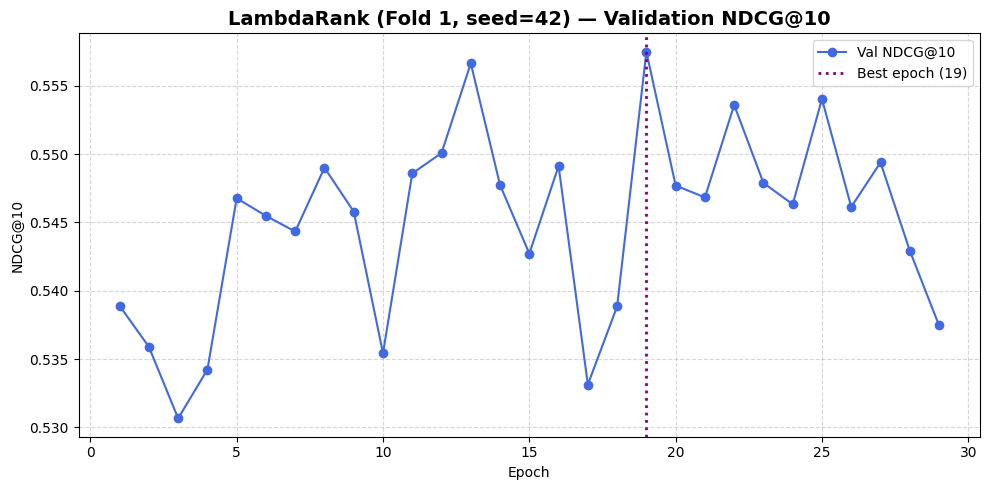

In [8]:
plot_training_curve(val_ndcg_history, "LambdaRank (Fold 1, seed=42)", k=10)


## Step 8 · Single-Fold Test Set Evaluation

In [9]:
test_ndcg = mean_ndcg(trained_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.3462
  NDCG@3  : 0.3802
  NDCG@5  : 0.4338
  NDCG@10 : 0.4735


## Results — Single-Fold (Fold 1, seed=42)

These results are not enough since the model may perform differently for different data, so we use the 5-fold results below for a fair assessment.

## Step 9 · 5-Fold Evaluation (Standard LETOR Folds)

We are using the exact 5 test splits provided by the dataset authors, rather than
shuffling and making our own cross-validation splits. This makes sure our results
can be fairly compared to published papers.

Each fold is trained across **3 random seeds** and results are reported as **Mean ± Std** (Fix #8).


In [10]:
def print_results_table(results, title, k_list=(1, 3, 5, 10)):
    """Pretty-print a cross_fold_eval or train_multiseed results dict."""
    summary = results.get("overall", results.get("summary", {}))
    print(f"\n{'═'*45}")
    print(f"  {title}")
    print(f"{'═'*45}")
    print(f"{'Metric':<10}  {'Mean':>8}  {'Std':>8}")
    print(f"{'─'*45}")
    for k in k_list:
        if k in summary:
            m, s = summary[k]["mean"], summary[k]["std"]
            print(f"NDCG@{k:<5}  {m:>8.4f}  {s:>8.4f}")
    print(f"{'═'*45}")


In [11]:
lambdarank_results = cross_fold_eval(
    model_fn=lambda: ScoringMLP(input_dim=46, hidden_dims=[64, 32], dropout=0.2),
    mode="lambdarank",
    base_path=DATA_PATH,
    folds=(1, 2, 3, 4, 5),
    seeds=SEEDS,
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    epochs=50,
    patience=10,
)

print_results_table(lambdarank_results, "LAMBDARANK — 5-Fold Results")



═══════════════════════════════════════════════════════
  FOLD 1 / 5
═══════════════════════════════════════════════════════


  Fold 1: 471 train | 157 val | 156 test queries
  NDCG@1  : 0.3483 ± 0.0149
  NDCG@3  : 0.3810 ± 0.0014
  NDCG@5  : 0.4311 ± 0.0041
  NDCG@10 : 0.4726 ± 0.0018

═══════════════════════════════════════════════════════
  FOLD 2 / 5
═══════════════════════════════════════════════════════


  Fold 2: 471 train | 156 val | 157 test queries
  NDCG@1  : 0.3312 ± 0.0046
  NDCG@3  : 0.3623 ± 0.0007
  NDCG@5  : 0.4120 ± 0.0035
  NDCG@10 : 0.4478 ± 0.0034

═══════════════════════════════════════════════════════
  FOLD 3 / 5
═══════════════════════════════════════════════════════


  Fold 3: 470 train | 157 val | 157 test queries
  NDCG@1  : 0.3645 ± 0.0070
  NDCG@3  : 0.3924 ± 0.0085
  NDCG@5  : 0.4388 ± 0.0034
  NDCG@10 : 0.4887 ± 0.0027

═══════════════════════════════════════════════════════
  FOLD 4 / 5
═══════════════════════════════════════════════════════


  Fold 4: 470 train | 157 val | 157 test queries
  NDCG@1  : 0.3963 ± 0.0265
  NDCG@3  : 0.4537 ± 0.0171
  NDCG@5  : 0.4970 ± 0.0118
  NDCG@10 : 0.5461 ± 0.0107

═══════════════════════════════════════════════════════
  FOLD 5 / 5
═══════════════════════════════════════════════════════


  Fold 5: 470 train | 157 val | 157 test queries
  NDCG@1  : 0.3800 ± 0.0121
  NDCG@3  : 0.4319 ± 0.0056
  NDCG@5  : 0.4793 ± 0.0058
  NDCG@10 : 0.5319 ± 0.0066

═══════════════════════════════════════════════════════
  OVERALL RESULTS (LAMBDARANK)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.3641 ± 0.0275
  NDCG@3  : 0.4043 ± 0.0348
  NDCG@5  : 0.4516 ± 0.0322
  NDCG@10 : 0.4974 ± 0.0371
═══════════════════════════════════════════════════════


═════════════════════════════════════════════
  LAMBDARANK — 5-Fold Results
═════════════════════════════════════════════
Metric          Mean       Std
─────────────────────────────────────────────
NDCG@1        0.3641    0.0275
NDCG@3        0.4043    0.0348
NDCG@5        0.4516    0.0322
NDCG@10       0.4974    0.0371
═════════════════════════════════════════════


## Results — 5-Fold Cross-Validation

- LambdaRank performed worse than Ranknet but the difference is negligible.
- Possible reasons:-
   - Statistical noise
   - The less number of Relevant documents compared to the irrelevant documents.the NDCG difference between swapping any two pairs is very small and similar across all pairs

## Step 10 · Save Results

In [12]:
import json

os.makedirs("/content/ltr_results", exist_ok=True)

def to_serialisable(obj):
    if isinstance(obj, dict):
        return {k: to_serialisable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serialisable(v) for v in obj]
    if isinstance(obj, (np.floating, float)):
        return float(obj)
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    return obj

with open("/content/ltr_results/lambdarank_results.json", "w") as f:
    json.dump(to_serialisable(lambdarank_results), f, indent=2)

print("Results saved to /content/ltr_results/lambdarank_results.json")


Results saved to /content/ltr_results/lambdarank_results.json


## Ablation Study — Architecture Comparison

We lock the data to **Fold 1** and swap out the underlying network architecture,
keeping everything else identical. This isolates the impact of depth and
dropout regularization on NDCG@10.

| Config | Hidden dims | Dropout |
|---|---|---|
| Linear | `[]` | 0.0 |
| Baseline | `[64, 32]` | 0.0 |
| Regularized | `[64, 32]` | 0.2 |
| Deep | `[128, 64, 32, 16]` | 0.2 |


In [13]:
# ── Lock data to Fold 1 ───────────────────────────────────────────────────────
train_loader_f1, val_loader_f1, test_loader_f1 = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)

# ── Ablation configurations ───────────────────────────────────────────────────
ablation_configs = {
    "Linear":      {"hidden_dims": [],              "dropout": 0.0},
    "Baseline":    {"hidden_dims": [64, 32],         "dropout": 0.0},
    "Regularized": {"hidden_dims": [64, 32],         "dropout": 0.2},
    "Deep":        {"hidden_dims": [128, 64, 32, 16],"dropout": 0.2},
}

ablation_results = {}

for arch_name, cfg in ablation_configs.items():
    print(f"\nTraining {arch_name} ...")
    result = train_multiseed(
        model_fn=lambda h=cfg["hidden_dims"], d=cfg["dropout"]: ScoringMLP(46, h, d),
        train_loader=train_loader_f1,
        val_loader=val_loader_f1,
        test_loader=test_loader_f1,
        mode="lambdarank",
        seeds=SEEDS,
        k_list=K_LIST,
        device=DEVICE,
        epochs=50,
        patience=10,
        verbose=False,
    )
    ablation_results[arch_name] = result["summary"]
    ndcg10 = result["summary"][10]
    print(f"  NDCG@10: {ndcg10['mean']:.4f} ± {ndcg10['std']:.4f}")


  Fold 1: 471 train | 157 val | 156 test queries

Training Linear ...
  NDCG@10: 0.4809 ± 0.0023

Training Baseline ...
  NDCG@10: 0.4750 ± 0.0074

Training Regularized ...
  NDCG@10: 0.4726 ± 0.0018

Training Deep ...
  NDCG@10: 0.4726 ± 0.0040


In [14]:
# ── Ablation results table ────────────────────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  ABLATION STUDY — NDCG@10 (Fold 1, Mean ± Std over 3 seeds)")
print(f"{'═'*65}")
print(f"{'Architecture':<15}  {'NDCG@1':>10}  {'NDCG@3':>10}  {'NDCG@5':>10}  {'NDCG@10':>10}")
print(f"{'─'*65}")
for arch_name, summary in ablation_results.items():
    row = "  ".join(
        f"{summary[k]['mean']:>6.4f}±{summary[k]['std']:.4f}" for k in [1, 3, 5, 10]
    )
    print(f"{arch_name:<15}  {row}")
print(f"{'═'*65}")



═════════════════════════════════════════════════════════════════
  ABLATION STUDY — NDCG@10 (Fold 1, Mean ± Std over 3 seeds)
═════════════════════════════════════════════════════════════════
Architecture         NDCG@1      NDCG@3      NDCG@5     NDCG@10
─────────────────────────────────────────────────────────────────
Linear           0.3390±0.0066  0.3937±0.0025  0.4411±0.0012  0.4809±0.0023
Baseline         0.3440±0.0253  0.3866±0.0065  0.4301±0.0089  0.4750±0.0074
Regularized      0.3483±0.0149  0.3810±0.0014  0.4311±0.0041  0.4726±0.0018
Deep             0.3497±0.0158  0.3819±0.0036  0.4280±0.0018  0.4726±0.0040
═════════════════════════════════════════════════════════════════


## Results — Ablation Study

- Because the NDCG weighted gradient is a stronger learning signal, even shallow architectures tend to achieve competitive NDCG.
- Dropout regularization remains useful to prevent overfitting on small folds.

## Conclusion

LambdaRank extends RankNet by weighting each training pair by its NDCG impact
($|\Delta\text{NDCG}_{ij}|$). This focuses the learning signal on swaps that
actually matter for the evaluation metric, typically leading to better NDCG scores
than plain RankNet — especially at shallow cutoffs like NDCG@1.
